# M7 · Lab 4 — SHAP Explainability
### Module 7 | Spine: Truck Delay Classification

| | |
|---|---|
| **Duration** | 60 min · **Difficulty** Intermediate · **Tier 3** |
| **Tools** | Python 3.12.10, `shap`, the real M3 model |
| **Prerequisite** | None beyond the shipped artifacts |
| **Builds toward** | "Why did the model say *delayed*?" — the answer regulators + ops ask for |

## 💻 Where to run this
Run on the **same SageMaker instance from M6** (auto-stops overnight — just **Start** it). New deps this module install in
the setup cell. Portable fallback: Colab / local Python 3.12.10. The **real** M3 artifacts ship in `data/` — nothing synthetic.

## Why explainability?
When the model flags a shipment as **delayed**, the operations lead asks *why* — and in a regulated/banking-adjacent
context (FreshBasket's finance team), "the model said so" is not an acceptable answer. **SHAP** (SHapley Additive
exPlanations) assigns each feature a contribution to each prediction, with a solid game-theoretic basis:
- **Global**: which features drive the model overall (summary / bar plots).
- **Local**: why *this one* shipment was flagged (force / waterfall plots).
- **Dependence**: how a single feature's effect changes across its range.
We explain the **real** Truck Delay XGBoost model on the **real** features.

## Step 1 · Setup + build the real model matrix

In [ ]:
# import sys, subprocess
# def _pip(*p): subprocess.run([sys.executable, "-m", "pip", "install", "-q", *p], check=True)
# try: import shap
# except ImportError: _pip("shap", "matplotlib"); import shap
# import matplotlib.pyplot as plt

In [1]:
%pip install shap matplotlib

In [2]:
!unzip data.zip

Archive:  data.zip
   creating: data/
   creating: data/artifacts/
  inflating: data/artifacts/encoder.pkl  
  inflating: data/artifacts/model_metadata.json  
  inflating: data/artifacts/scaler.pkl  
  inflating: data/artifacts/xgboost_model.pkl  
   creating: data/reference/
  inflating: data/reference/feature_metadata.json  
  inflating: data/reference/final_features.csv  


In [3]:
import shap
import matplotlib.pyplot as plt
import os, json
import numpy as np, pandas as pd

DATA_DIR  = os.environ.get("M7_DATA_DIR", "data")
REF_CSV   = os.path.join(DATA_DIR, "reference", "final_features.csv")
ART_DIR   = os.path.join(DATA_DIR, "artifacts")
assert os.path.exists(REF_CSV), f"Real reference frame missing at {REF_CSV} (ships in Module 7/labs/data/)."

ref = pd.read_csv(REF_CSV)
fmeta = json.load(open(os.path.join(DATA_DIR, "reference", "feature_metadata.json")))
print("Reference:", ref.shape, "| target rate:", round(ref[fmeta["target"]].mean(), 4))

Reference: (12308, 37) | target rate: 0.3489


In [4]:
# Reuse the EXACT M3 inference preprocessing (scale -> one-hot -> passthrough -> reorder to 128 features)
import joblib
_model   = joblib.load(os.path.join(ART_DIR, "xgboost_model.pkl"))
_encoder = joblib.load(os.path.join(ART_DIR, "encoder.pkl"))
_scaler  = joblib.load(os.path.join(ART_DIR, "scaler.pkl"))
mmeta = json.load(open(os.path.join(ART_DIR, "model_metadata.json")))
M_CONT, M_CAT, M_BIN, M_FEATS = (mmeta["continuous_cols"], mmeta["categorical_cols"],
                                 mmeta["binary_ordinal_cols"], mmeta["feature_names"])

def to_model_matrix(df):
    x_cont = pd.DataFrame(_scaler.transform(df[M_CONT]), columns=M_CONT)
    x_cat  = pd.DataFrame(_encoder.transform(df[M_CAT]), columns=_encoder.get_feature_names_out(M_CAT))
    x_bin  = df[M_BIN].reset_index(drop=True)
    return pd.concat([x_cont, x_cat, x_bin], axis=1)[M_FEATS]
print("Preprocessing helper ready — produces the 128-feature model matrix.")

Preprocessing helper ready — produces the 128-feature model matrix.


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [5]:
# Explain on a representative sample of the REAL data (TreeExplainer is exact + fast for XGBoost)
sample = ref.sample(1000, random_state=42).reset_index(drop=True)
X = to_model_matrix(sample)
print("Explaining", X.shape[0], "real rows ×", X.shape[1], "features")

Explaining 1000 real rows × 128 features


## Step 2 · Compute SHAP values (exact, via TreeExplainer)

In [6]:
explainer = shap.TreeExplainer(_model)
shap_values = explainer.shap_values(X)
print("SHAP values:", np.array(shap_values).shape)

SHAP values: (1000, 128)


## Step 3 · Global explanation — what drives delays overall?
The summary (beeswarm) shows direction + magnitude per feature; the bar plot ranks mean importance. Expect weather
(precip/humidity/visibility), route distance/hours, and traffic to dominate — the monsoon story from M6, quantified.

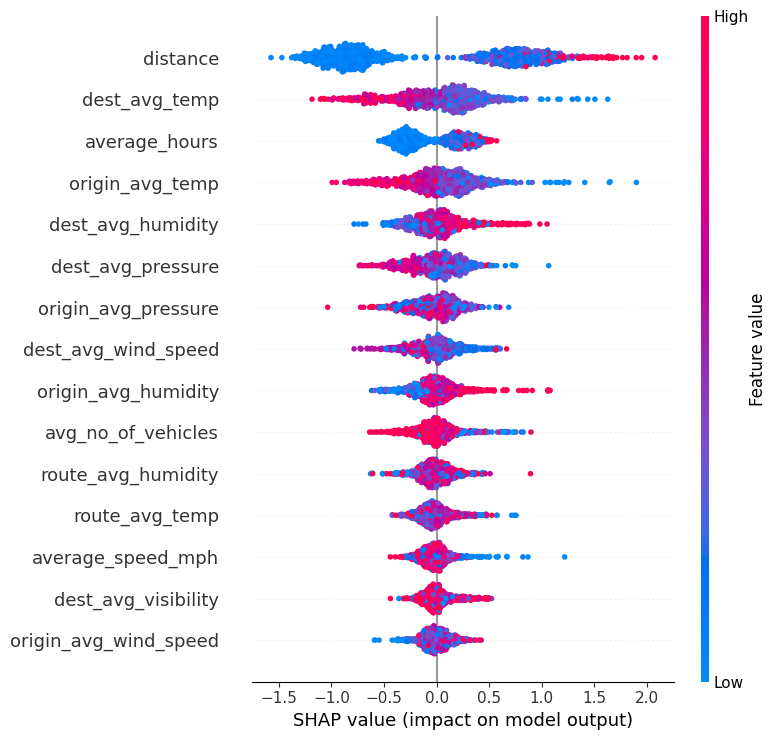

In [7]:
shap.summary_plot(shap_values, X, max_display=15, show=True)

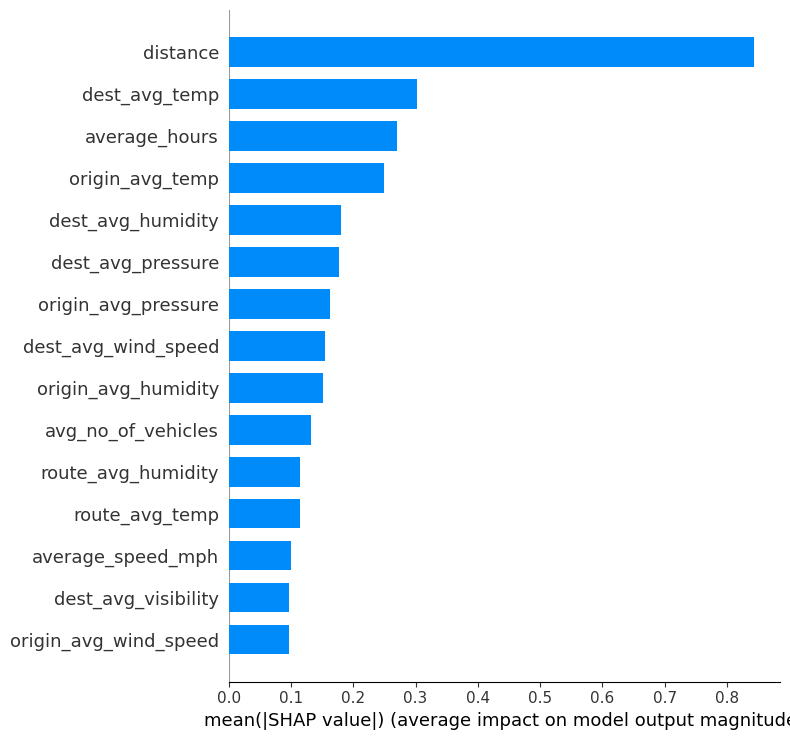

In [8]:
shap.summary_plot(shap_values, X, plot_type="bar", max_display=15, show=True)

## Step 4 · Local explanation — why was *this* shipment flagged?
Pick one predicted-delayed row and show its force/waterfall: the features pushing toward "delayed" (red) vs "on-time"
(blue). This is the chart you put in front of the ops lead.

Explaining row 1 (predicted delayed)


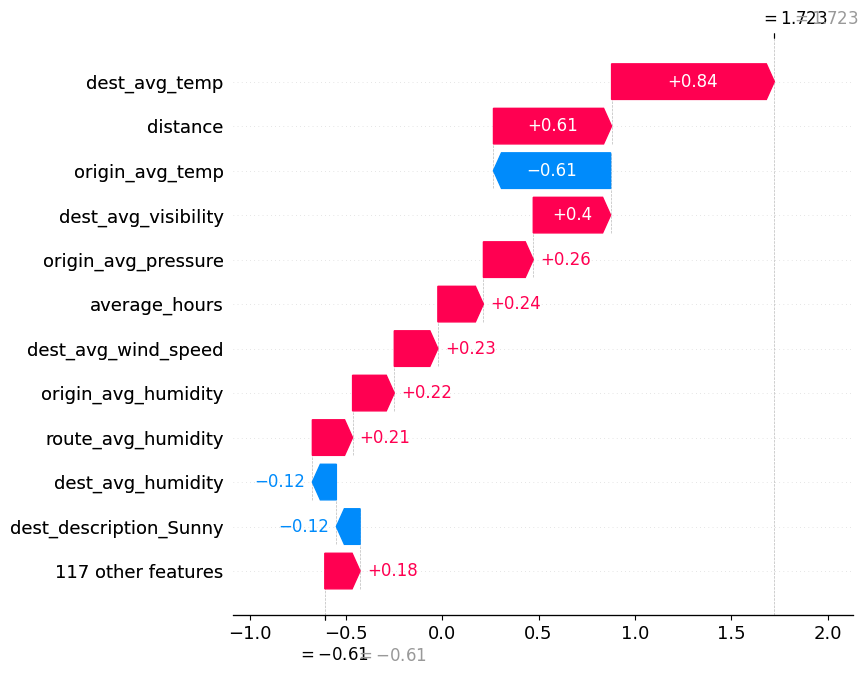

In [9]:
pred = _model.predict(X)
idx = int(np.where(pred == 1)[0][0])   # first predicted-delayed row
print("Explaining row", idx, "(predicted delayed)")
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value, shap_values[idx], feature_names=list(X.columns), max_display=12, show=True)

## Step 5 · Dependence — how does one feature's effect change across its range?
`route_avg_precip` is the headline monsoon feature. The dependence plot shows the SHAP contribution rising as precip
rises — and colours by an interacting feature SHAP picks automatically.

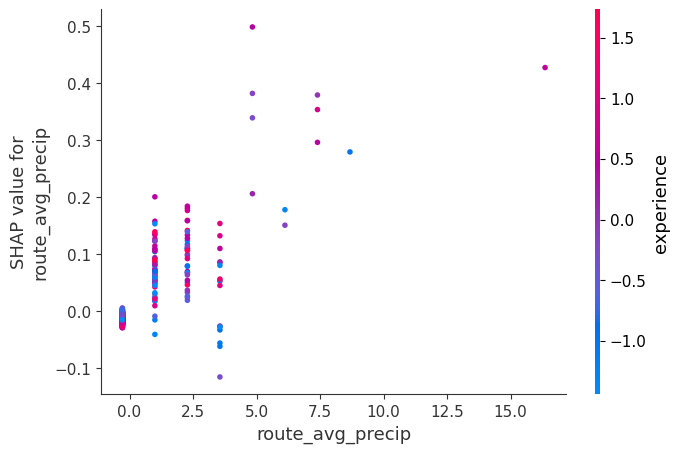

In [10]:
shap.dependence_plot("route_avg_precip", shap_values, X, show=True)

## Step 6 · Tie it back to the monitoring story (M6)
The features SHAP ranks highest are exactly the ones whose **drift** would hurt accuracy most. A production-grade move:
**weight the M6 drift alert by SHAP importance** — drift in a top-5 SHAP feature is far more urgent than drift in a
feature the model barely uses. (M8's pipeline can encode this.)

## Verification Checklist
- [ ] SHAP values computed for 1,000 **real** rows via `TreeExplainer`
- [ ] Global summary + bar plots rendered; you can name the top 5 delay drivers
- [ ] A local waterfall explains one predicted-delayed shipment
- [ ] A dependence plot for `route_avg_precip` shows the monsoon effect
- [ ] You can connect SHAP importance to M6 drift severity

## Troubleshooting
| Symptom | Fix |
|---|---|
| `shap` import error on `numpy>=2` | `pip install "numpy<2" shap` (matches the course pin) |
| force/waterfall not rendering inline | use `matplotlib=True` variants or `shap.initjs()`; the waterfall_legacy call above is matplotlib-based |
| values shape is a list of 2 arrays | older SHAP returns per-class; for binary XGBoost use index `[1]` or the array as shown |